# Phase 3 — GENIE BPC external validation (pancreas pilot)

Figures for the **frozen** model (fit on MSK train+val, zero retraining) applied to
**551 pancreas patients from NON-MSK centers** (DFCI / VICC / UHN). Reads `results/external_genie_panc.json`
and `data/processed/external_panc_patients.parquet` — it does not recompute the model.

Two figures:
1. **Internal vs external C-index** (tab vs both) — does the embedding's contribution transfer outside MSK?
2. **KM curves** for high/low risk in the external cohort (intra-external cutpoint) — clinical discrimination.

The PNG figures are saved to `data/processed/figures/` (gitignored); in the repo they stay embedded
in this `.ipynb`. Convention: all labels, comments and narrative in English.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Run from repo root or notebooks/ — resolve either way.
ROOT = Path.cwd()
ROOT = ROOT if (ROOT / 'results').exists() else ROOT.parent
FIGDIR = ROOT / 'data/processed/figures'  # gitignored; PNGs live here, not in notebooks/
FIGDIR.mkdir(parents=True, exist_ok=True)

ext = json.loads((ROOT / 'results/external_genie_panc.json').read_text())
internal = json.loads((ROOT / 'results/embedding_grid__medgemma15.json').read_text())
pat = pd.read_parquet(ROOT / 'data/processed/external_panc_patients.parquet')

CT = 'Pancreatic Cancer'
cidx = {
    'Internal (MSK test)': {
        'tab': internal['feature_sets']['tab']['c_index_per_cancer_test'][CT],
        'both': internal['feature_sets']['both']['c_index_per_cancer_test'][CT],
    },
    'External (GENIE non-MSK)': {
        'tab': ext['feature_sets']['tab']['concordance'],
        'both': ext['feature_sets']['both']['concordance'],
    },
}
print(f"External n={ext['external_n']}, events={ext['feature_sets']['both']['events']}")
cidx

External n=551, events=470


{'Internal (MSK test)': {'tab': 0.6493769658843455,
  'both': 0.6879385434309219},
 'External (GENIE non-MSK)': {'tab': 0.7150320325719901,
  'both': 0.7253400920705529}}

## Figure 1 — C-index: internal vs external, tab vs both

If the `both` bars stay above `tab` in the external cohort too, the semantic contribution of the
MedGemma embedding **transfers** to unseen institutions (it was not overfitting to MSK).

Internal (MSK test): both - tab = +0.0386
External (GENIE non-MSK): both - tab = +0.0103


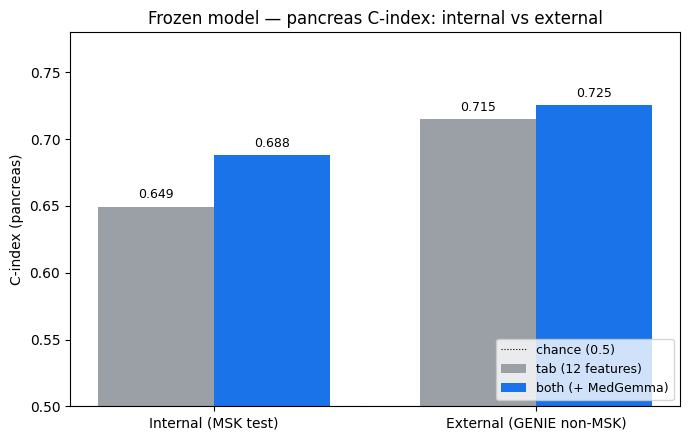

In [2]:
groups = list(cidx.keys())
x = np.arange(len(groups))
w = 0.36
fig, ax = plt.subplots(figsize=(7, 4.5))
tab_vals = [cidx[g]['tab'] for g in groups]
both_vals = [cidx[g]['both'] for g in groups]
b1 = ax.bar(x - w/2, tab_vals, w, label='tab (12 features)', color='#9aa0a6')
b2 = ax.bar(x + w/2, both_vals, w, label='both (+ MedGemma)', color='#1a73e8')
for bars in (b1, b2):
    for r in bars:
        ax.text(r.get_x() + r.get_width()/2, r.get_height() + 0.004,
                f'{r.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.axhline(0.5, ls=':', c='k', lw=0.8, label='chance (0.5)')
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel('C-index (pancreas)'); ax.set_ylim(0.5, 0.78)
ax.set_title('Frozen model — pancreas C-index: internal vs external')
ax.legend(loc='lower right', fontsize=9)
for d, g in zip([cidx[g]['both'] - cidx[g]['tab'] for g in groups], groups):
    print(f'{g}: both - tab = {d:+.4f}')
plt.tight_layout()
plt.savefig(FIGDIR / 'fig_external_cindex.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 — Kaplan–Meier high/low risk in the external cohort (`both` model)

Split at the **intra-external** median of risk (balanced groups → clean discrimination). A wide
separation with a highly significant log-rank = the frozen model's risk stratifies survival in
patients from other institutions.

median OS  high=11.2 m  low=31.0 m  | log-rank p=1.78e-36


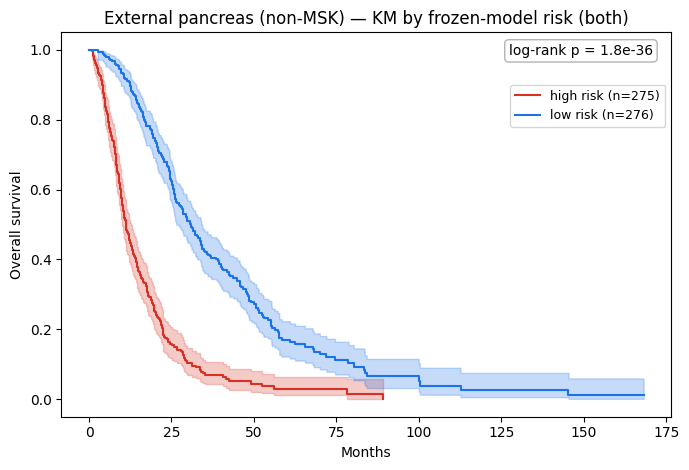

In [3]:
risk = pat['risk_both'].to_numpy()
high = risk > np.median(risk)
t, e = pat['os_months'].to_numpy(), pat['event'].to_numpy()
lr = logrank_test(t[high], t[~high], e[high], e[~high])

fig, ax = plt.subplots(figsize=(7, 4.8))
kmf = KaplanMeierFitter()
for mask, label, color in [(high, 'high risk', '#d93025'), (~high, 'low risk', '#1a73e8')]:
    kmf.fit(t[mask], e[mask], label=f'{label} (n={int(mask.sum())})')
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True)
ax.set_xlabel('Months'); ax.set_ylabel('Overall survival')
ax.set_title('External pancreas (non-MSK) — KM by frozen-model risk (both)')
p = lr.p_value
ax.text(0.97, 0.97, f'log-rank p = {p:.1e}', transform=ax.transAxes,
        ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round', fc='white', ec='0.7'))
ax.legend(loc='upper right', bbox_to_anchor=(1.0, 0.88), fontsize=9)
km = ext['feature_sets']['both']['km_intra_external_median']['median_os']
print(f"median OS  high={km['high']:.1f} m  low={km['low']:.1f} m  | log-rank p={p:.2e}")
plt.tight_layout()
plt.savefig(FIGDIR / 'fig_external_km.png', dpi=150, bbox_inches='tight')
plt.show()

## Reading

- **Generalizes without leakage:** the frozen model keeps a C-index of ~0.72–0.73 in pancreas from
  DFCI/VICC/UHN (never-seen institutions) — it raises the venue ceiling to a *paper with real external
  validation*.
- **The embedding transfers:** `both` > `tab` in the external cohort too (+~0.01), consistent with
  Phase 1 where pancreas was the engine of MedGemma's contribution.
- **Strong clinical signal:** wide KM separation (median OS ~11 vs ~31 months) with log-rank
  p ≪ 1e-30 and HR/SD 1.67 [1.50, 1.85] adjusted for age + stage.
- **Caveat:** high external event rate (~85%, advanced pancreas dominates the BPC cohort); the MSK
  pan-cancer median cutpoint is unbalanced (see JSON) — the intra-external cutpoint is the clean
  discrimination.